In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.6f}'.format)

(array([1.186e+03, 1.438e+03, 8.330e+02, 3.860e+02, 1.260e+02, 2.400e+01,
        6.000e+00, 1.000e+00, 0.000e+00, 0.000e+00]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

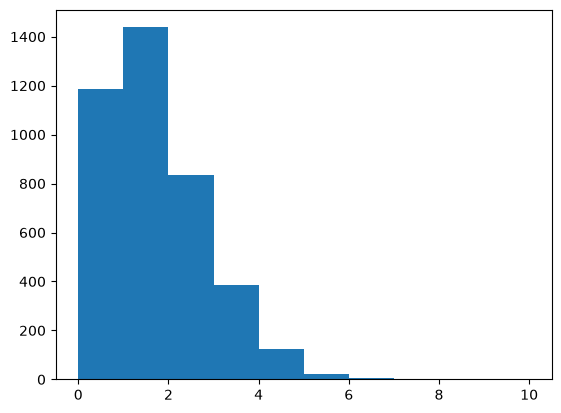

In [2]:
data = pd.read_csv('data.txt', comment='#', header=None, names=['n'])
#dt1
plt.hist(data, bins=np.linspace(0, 10, 11))

(array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
         1.,  1.,  2.,  5.,  2.,  3.,  8., 11., 12., 21., 18., 20., 21.,
        14., 11.,  9., 11.,  9.,  2.,  4.,  4.,  2.,  4.,  2.,  0.,  1.,
         0.,  0.,  0.,  0.,  0.,  1.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45.]),
 <BarContainer object of 45 artists>)

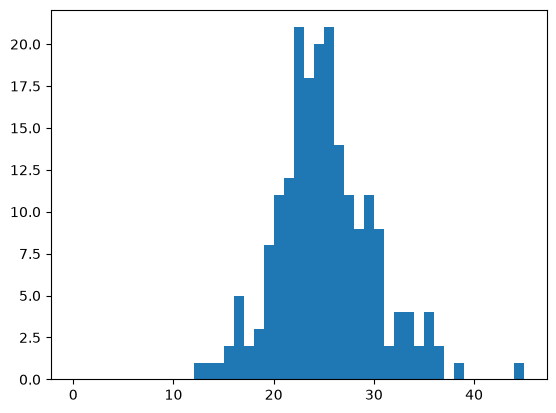

In [3]:
dt1 = data.groupby(data.index // 1)['n'].sum()
dt10 = data.groupby(data.index // 10)['n'].sum()
dt20 = data.groupby(data.index // 20)['n'].sum()
dt40 = data.groupby(data.index // 40)['n'].sum()
dt80 = data.groupby(data.index // 80)['n'].sum()
plt.hist(dt20, bins=np.linspace(0, 45, 46))

In [4]:
result = pd.DataFrame()
t = [1, 10, 20, 40, 80]
# t = list(range(1, 4000 + 1))
# t = [i for i in range(1, 4000 + 1) if 4000 % i == 0]
result['t'] = t
dts = [data.groupby(data.index // i)['n'].sum() for i in t]
result['len'] = list(map(len, dts))
result['n_mean'] = list(map(np.mean, dts))
result['sqrt_mean'] = np.sqrt(result['n_mean'])
result['n_std'] = list(map(lambda x: np.std(x, ddof=1), dts))
result['n_sem'] = result['n_std'] / np.sqrt(result['len'])
result['eps'] = result['n_sem'] / result['n_mean']
result['j'] = result['n_mean'] / result['t']
result['sigma_j'] = result['n_sem'] / result['t']
result['<=1stdc'] = list(map(lambda x: x[np.abs(x - x.mean()) < np.std(x, ddof=1)].count(), dts))
result['<=1std'] = list(map(lambda x: x[np.abs(x - x.mean()) < np.std(x, ddof=1)].count() / len(x), dts))
result['<=2stdc'] = list(map(lambda x: x[np.abs(x - x.mean()) < 2 * np.std(x, ddof=1)].count(), dts))
result['<=2std'] = list(map(lambda x: x[np.abs(x - x.mean()) < 2 * np.std(x, ddof=1)].count() / len(x), dts))
result['<=3stdc'] = list(map(lambda x: x[np.abs(x - x.mean()) < 3 * np.std(x, ddof=1)].count(), dts))
result['<=3std'] = list(map(lambda x: x[np.abs(x - x.mean()) < 3 * np.std(x, ddof=1)].count() / len(x), dts))
result

,t,len,n_mean,sqrt_mean,n_std,n_sem,eps,j,sigma_j,<=1stdc,<=1std,<=2stdc,<=2std,<=3stdc,<=3std
0,1,4000,1.232250,1.110068,1.123889,0.017770,0.014421,1.232250,0.017770,2271,0.567750,3843,0.960750,3969,0.992250
1,10,400,12.322500,3.510342,3.628555,0.181428,0.014723,1.232250,0.018143,274,0.685000,381,0.952500,397,0.992500
2,20,200,24.645000,4.964373,4.891689,0.345895,0.014035,1.232250,0.017295,148,0.740000,189,0.945000,199,0.995000
3,40,100,49.290000,7.020684,6.938831,0.693883,0.014078,1.232250,0.017347,72,0.720000,95,0.950000,100,1.000000
4,80,50,98.580000,9.928746,10.006304,1.415105,0.014355,1.232250,0.017689,32,0.640000,50,1.000000,50,1.000000


In [5]:
result[['t', 'n_mean', 'sqrt_mean', 'n_std', 'n_sem', 'eps']]

,t,n_mean,sqrt_mean,n_std,n_sem,eps
0,1,1.232250,1.110068,1.123889,0.017770,0.014421
1,10,12.322500,3.510342,3.628555,0.181428,0.014723
2,20,24.645000,4.964373,4.891689,0.345895,0.014035
3,40,49.290000,7.020684,6.938831,0.693883,0.014078
4,80,98.580000,9.928746,10.006304,1.415105,0.014355


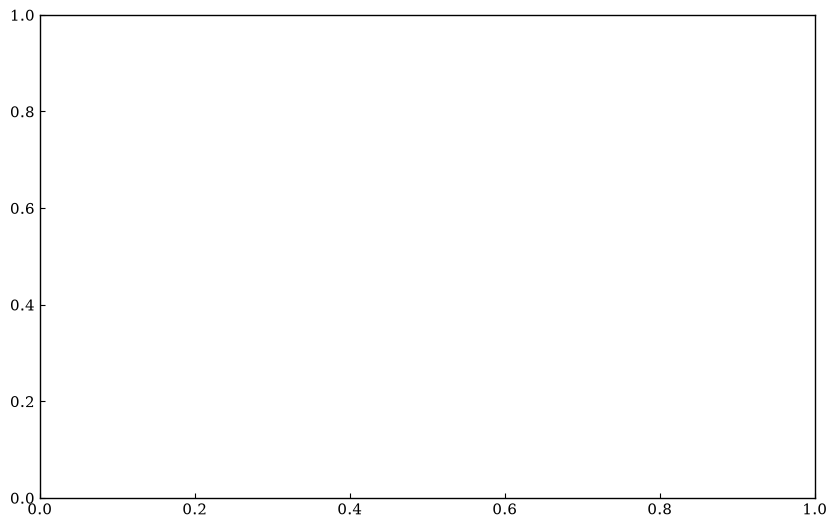

In [6]:
# Глобальные настройки для строгого научного стиля оформления графика
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.linewidth': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'legend.frameon': True,
    'legend.edgecolor': 'black'
})

# Настройка полотна. Оставляем больше места сверху (top=0.72) для трех дополнительных осей.
fig, ax1 = plt.subplots(figsize=(10, 7))
fig.subplots_adjust(top=0.8)

# Цветовая палитра: глубокие и контрастные цвета вместо неоновых
c10 = '#1f77b4ff' # Классический синий
c20 = '#2ca02cff' # Строгий зеленый
c40 = '#d62728aa' # Кирпично-красный
c80 = '#444444aa' # Темно-серый
c_pois = '#ff7f0eff' # Оранжевый
c_gauss = '#9467bdff' # Фиолетовый

#plt.savefig("images/gauss.pdf", format="pdf")

In [7]:
# === 1. Базовая ось (ax1) для tau = 10 с ===
bins_10 = np.arange(dt10.min() - 0.5, dt10.max() + 1.5, 1)
weights_10 = np.ones_like(dt10) / len(dt10)

# Заливаем только самую младшую гистограмму, чтобы она служила фоном
h1 = ax1.hist(dt10, bins=bins_10, weights=weights_10,
              color=c10, alpha=0.6, edgecolor=c10,
              label=f'$\\tau={t[1]}$ с')

ax1.set_xlabel('Число отсчётов $n$')
ax1.set_ylabel('Доля случаев $w_n$')
ax1.tick_params(axis='x', colors=c10)

ax1.set_xlim(0, (dt10.max() // 5 + 1) * 5)
xlim1 = ax1.get_xlim()

In [8]:
# === 2. Дополнительная ось (ax2) для tau = 20 с ===
ax2 = ax1.twiny()
bins_20 = np.arange(dt20.min() - 0.5, dt20.max() + 1.5, 1)
weights_20 = np.ones_like(dt20) / len(dt20)

# Остальные гистограммы делаем контурными (histtype='step')
h2 = ax2.hist(dt20, bins=bins_20, weights=weights_20,
              color=c20, alpha=0.6, edgecolor=c20, linewidth=2,
              label=f'$\\tau={t[2]}$ с')
ax2.set_xlim(xlim1[0] * (t[2] / t[1]), xlim1[1] * (t[2] / t[1]))
ax2.tick_params(axis='x', colors=c20)

In [9]:
# === 3. Дополнительная ось (ax3) для tau = 40 с ===
ax3 = ax1.twiny()
ax3.spines['top'].set_position(('axes', 1.10))
bins_40 = np.arange(dt40.min() - 0.5, dt40.max() + 1.5, 1)
weights_40 = np.ones_like(dt40) / len(dt40)

h3 = ax3.hist(dt40, bins=bins_40, weights=weights_40,
              histtype='step', color=c40, linewidth=2, # alpha=0.3, edgecolor=c40,
              label=f'$\\tau={t[3]}$ с')
ax3.set_xlim(xlim1[0] * (t[3] / t[1]), xlim1[1] * (t[3] / t[1]))
ax3.tick_params(axis='x', colors=c40)

In [10]:
# === 4. Дополнительная ось (ax4) для tau = 80 с ===
#ax4 = ax1.twiny()
#ax4.spines['top'].set_position(('axes', 1.20))
#bins_80 = np.arange(dt80.min() - 0.5, dt80.max() + 1.5, 1)
#weights_80 = np.ones_like(dt80) / len(dt80)

# Для отличия можно добавить пунктирный стиль линии
#h4 = ax4.hist(dt80, bins=bins_80, weights=weights_80,
#              histtype='step', color=c80, linewidth=2, #linestyle='--',
#              label=f'$\\tau={t[4]}$ с')
#ax4.set_xlim(xlim1[0] * (t[4] / t[1]), xlim1[1] * (t[4] / t[1]))
#ax4.tick_params(axis='x', colors=c80)

In [11]:
from scipy.stats import norm
from scipy.special import gamma

# === 5. Теоретические кривые для базового распределения (tau=10) ===
mean_10 = np.mean(dt10)
std_10 = np.std(dt10, ddof=1)

x_smooth = np.linspace(0, int(xlim1[1]) + 2, 500)

# Пуассон (сглаженный)
y_pois = (mean_10**x_smooth * np.exp(-mean_10)) / gamma(x_smooth + 1)
p1, = ax1.plot(x_smooth, y_pois, color=c_pois, linewidth=2.5,
               label='Распределение Пуассона')

# Гаусс
y_gauss = (1 / (np.sqrt(2 * np.pi) * std_10)) * np.e ** (- (((x_smooth - mean_10)/(np.sqrt(2) * std_10)) ** 2))
#y_gauss = norm.pdf(x_smooth, loc=mean_10, scale=std_10)
p2, = ax1.plot(x_smooth, y_gauss, color=c_gauss, linewidth=2.5, linestyle=':',
               label='Распределение Гаусса')

# === Сбор элементов в легенду ===
handles = [
    p1,
    p2,
    h1[2][0],
    h2[2][0],
    h3[2][0],
#    h4[2][0]
]
labels = [
    'Распределение Пуассона',
    'Распределение Гаусса',
    f'$\\tau={t[1]}$ с',
    f'$\\tau={t[2]}$ с',
    f'$\\tau={t[3]}$ с',
#    f'$\\tau={t[4]}$ с'
]
ax1.legend(handles, labels, loc='upper right', framealpha=0.95)
    
# Легкая сетка только по оси Y, чтобы не ломать читаемость 4-х шкал X
ax1.grid(axis='y', linestyle='--', alpha=0.5)

fig
fig.savefig("images/gauss.pdf", format="pdf")
plt.show()